### 1. Configuración y Carga de Datos

In [4]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import pyarrow as pa

In [5]:
# Configuración inicial para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
# --- Cargar los datos ---
file_path = "../data/raw/fires-all.csv"

In [7]:
try:
    # Cargar con polars, infiriendo el esquema automáticamente
    df = pl.read_csv(file_path, try_parse_dates=True)
    print(f'Dataset cargado. Dimensiones: {df.shape}')
except Exception as e:
    print(f'Error al cargar el archivo: {e}')

Dataset cargado. Dimensiones: (292181, 21)


### 2. Visión General y Limpieza Inicial
##### 2.1. Estructura y Tipos de Datos

In [8]:
# Mostrar las primeras filas y el esquema
print("----- Primeras 5 filas -----")
print(df.head())

print("\n----- Esquema del DataFrame -----")
print(df.schema)

----- Primeras 5 filas -----
shape: (5, 21)
┌────────────┬────────────┬────────────┬──────┬───┬──────────┬────────┬────────┬──────────┐
│ id         ┆ superficie ┆ fecha      ┆ lat  ┆ … ┆ personal ┆ medios ┆ gastos ┆ perdidas │
│ ---        ┆ ---        ┆ ---        ┆ ---  ┆   ┆ ---      ┆ ---    ┆ ---    ┆ ---      │
│ i64        ┆ f64        ┆ date       ┆ str  ┆   ┆ i64      ┆ i64    ┆ i64    ┆ i64      │
╞════════════╪════════════╪════════════╪══════╪═══╪══════════╪════════╪════════╪══════════╡
│ 1968290001 ┆ 14.0       ┆ 1968-01-01 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968430003 ┆ 3.0        ┆ 1968-01-03 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968290006 ┆ 2.0        ┆ 1968-01-06 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968120007 ┆ 8.2        ┆ 1968-01-07 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968430016 ┆ 600.0      ┆ 1968-01-07 ┆ null ┆ … ┆ 35       ┆ 1      ┆ 0      ┆ 0        │
└────────────┴────────────┴─────────

In [9]:
# Resumen estadístico de columnas numéricas
print("\n----- Resumen Estadístico (Numéricas) -----")
print(df.describe())


----- Resumen Estadístico (Numéricas) -----
shape: (9, 22)
┌────────────┬──────────┬───────────┬───────────┬───┬───────────┬──────────┬───────────┬───────────┐
│ statistic  ┆ id       ┆ superfici ┆ fecha     ┆ … ┆ personal  ┆ medios   ┆ gastos    ┆ perdidas  │
│ ---        ┆ ---      ┆ e         ┆ ---       ┆   ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ str        ┆ f64      ┆ ---       ┆ str       ┆   ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
│            ┆          ┆ f64       ┆           ┆   ┆           ┆          ┆           ┆           │
╞════════════╪══════════╪═══════════╪═══════════╪═══╪═══════════╪══════════╪═══════════╪═══════════╡
│ count      ┆ 292181.0 ┆ 292181.0  ┆ 292181    ┆ … ┆ 292181.0  ┆ 292181.0 ┆ 292181.0  ┆ 292181.0  │
│ null_count ┆ 0.0      ┆ 0.0       ┆ 0         ┆ … ┆ 0.0       ┆ 0.0      ┆ 0.0       ┆ 0.0       │
│ mean       ┆ 1.9952e9 ┆ 26.751764 ┆ 1995-05-2 ┆ … ┆ 22.088757 ┆ 2.065531 ┆ 593.28045 ┆ 8461.0676 │
│            ┆          ┆      

> <br/>
> 💡 Observaciones Iniciales:
>
> - Rango temporal: 1968-2023. => Rango objetivo: 2013 - 2023.
> - Columnas Clave: superficie, fecha, lat, lng, gastos, perdidas, etc.
> - Datos Faltantes: Según la documentación, campos como gastos y perdidas tienen muchos valores nulos. time_ctrl, time_ext, personal, medios también. => Filtrar por las columnas objetivo del análisis.
> - Columnas de tipo id: idcomunidad, idprovincia
>
> <br/>


##### 2.2. Limpieza de Datos y Manejo de Nulos

In [10]:
# Diccionarios de mapeo (basados en el estándar INE)

# Comunidades Autónomas (códigos INE)
comunidad_map = {
    1: 'Andalucía',
    2: 'Aragón',
    3: 'Asturias',
    4: 'Baleares',
    5: 'Canarias',
    6: 'Cantabria',
    7: 'Castilla-La Mancha',
    8: 'Castilla y León',
    9: 'Cataluña',
    10: 'Comunidad Valenciana',
    11: 'Extremadura',
    12: 'Galicia',
    13: 'Madrid',
    14: 'Murcia',
    15: 'Navarra',
    16: 'País Vasco',
    17: 'La Rioja'
    # Nota: Ceuta y Melilla podrían tener códigos 18 y 19
}

In [11]:
# Diccionario de provincias (códigos INE 01-52)
provincia_map = {
    1: 'Álava', 2: 'Albacete', 3: 'Alicante', 4: 'Almería', 5: 'Ávila',
    6: 'Badajoz', 7: 'Baleares', 8: 'Barcelona', 9: 'Burgos', 10: 'Cáceres',
    11: 'Cádiz', 12: 'Castellón', 13: 'Ciudad Real', 14: 'Córdoba', 15: 'A Coruña',
    16: 'Cuenca', 17: 'Girona', 18: 'Granada', 19: 'Guadalajara', 20: 'Guipúzcoa',
    21: 'Huelva', 22: 'Huesca', 23: 'Jaén', 24: 'León', 25: 'Lleida',
    26: 'La Rioja', 27: 'Lugo', 28: 'Madrid', 29: 'Málaga', 30: 'Murcia',
    31: 'Navarra', 32: 'Ourense', 33: 'Asturias', 34: 'Palencia', 35: 'Las Palmas',
    36: 'Pontevedra', 37: 'Salamanca', 38: 'Santa Cruz de Tenerife', 39: 'Cantabria',
    40: 'Segovia', 41: 'Sevilla', 42: 'Soria', 43: 'Tarragona', 44: 'Teruel',
    45: 'Toledo', 46: 'Valencia', 47: 'Valladolid', 48: 'Vizcaya', 49: 'Zamora',
    50: 'Zaragoza', 51: 'Ceuta', 52: 'Melilla'
}

In [12]:
# Renombrado de columnas id
df = df.with_columns([
    pl.col("idcomunidad").replace_strict(comunidad_map, default="Desconocido").alias("comunidad_autonoma"),
    pl.col("idprovincia").replace_strict(provincia_map, default="Desconocido").alias("provincia"),
])

In [13]:
# Renombrado de columnas objetivo
df = df.rename({
    'superficie': 'superficie_quemada',  # variable objetivo
    'fecha': 'fecha_incendio',
    'lat': 'latitud',
    'lng': 'longitud',
    'causa': 'causa_incendio'
})

In [14]:
# Filtrar por las columnas objetivo del análisis
columnas_objetivo = [
    'id', 'superficie_quemada', 'fecha_incendio', 'latitud', 'longitud',
    'comunidad_autonoma', 'provincia', 'causa_incendio'
]

df = df.select(columnas_objetivo)

In [15]:
# Resumen de columnas
print("\n----- Resumen -----")
print(df.columns)


----- Resumen -----
['id', 'superficie_quemada', 'fecha_incendio', 'latitud', 'longitud', 'comunidad_autonoma', 'provincia', 'causa_incendio']


### 3. Análisis Univariante (Distribuciones)
##### 3.1. Variables Numéricas: superficie_quemada, latitud y longitud

In [16]:
# Primero, verificar el rango temporal y filtrar por el período objetivo (2013-2023)
print("\n----- Rango de fechas -----")
print(f"Fecha mínima: {df['fecha_incendio'].min()}")
print(f"Fecha máxima: {df['fecha_incendio'].max()}")


----- Rango de fechas -----
Fecha mínima: 1968-01-01
Fecha máxima: 2023-12-08


In [17]:
# Filtrar por el período 2013-2023
df = df.filter(
    (pl.col('fecha_incendio').dt.year() >= 2013) & 
    (pl.col('fecha_incendio').dt.year() <= 2023)
)

print(f"\nDatos después de filtrar por período 2013-2023: {df.shape}")


Datos después de filtrar por período 2013-2023: (27289, 8)


In [18]:
# Verificar nulos después del filtrado
null_percent_filtrado = df.select([
    pl.col(col).is_null().mean().round(4) * 100 for col in df.columns
])
print("\n----- Porcentaje de Nulos después del filtrado -----")
print(null_percent_filtrado)


----- Porcentaje de Nulos después del filtrado -----
shape: (1, 8)
┌─────┬──────────────┬──────────────┬─────────┬──────────┬──────────────┬───────────┬──────────────┐
│ id  ┆ superficie_q ┆ fecha_incend ┆ latitud ┆ longitud ┆ comunidad_au ┆ provincia ┆ causa_incend │
│ --- ┆ uemada       ┆ io           ┆ ---     ┆ ---      ┆ tonoma       ┆ ---       ┆ io           │
│ f64 ┆ ---          ┆ ---          ┆ f64     ┆ f64      ┆ ---          ┆ f64       ┆ ---          │
│     ┆ f64          ┆ f64          ┆         ┆          ┆ f64          ┆           ┆ f64          │
╞═════╪══════════════╪══════════════╪═════════╪══════════╪══════════════╪═══════════╪══════════════╡
│ 0.0 ┆ 0.0          ┆ 0.0          ┆ 0.0     ┆ 0.0      ┆ 0.0          ┆ 0.0       ┆ 0.0          │
└─────┴──────────────┴──────────────┴─────────┴──────────┴──────────────┴───────────┴──────────────┘


In [19]:
# Para el análisis, consideramos que 'superficie_quemada' es la variable más importante
df = df.drop_nulls(subset=['superficie_quemada', 'latitud', 'longitud'])

print(f"\nDatos después de eliminar nulos en columnas críticas: {df.shape}")


Datos después de eliminar nulos en columnas críticas: (27288, 8)


In [20]:
# Crear columnas auxiliares para el análisis temporal
df = df.with_columns([
    pl.col('fecha_incendio').dt.year().alias('año'),
    pl.col('fecha_incendio').dt.month().alias('mes'),
    pl.col('fecha_incendio').dt.quarter().alias('trimestre')
])

print(f"\nColumnas disponibles después de limpieza: {df.columns}")


Columnas disponibles después de limpieza: ['id', 'superficie_quemada', 'fecha_incendio', 'latitud', 'longitud', 'comunidad_autonoma', 'provincia', 'causa_incendio', 'año', 'mes', 'trimestre']


##### 3.2 Análisis Univariante - Variables Numéricas

In [21]:
# Usamos describe() sobre el DataFrame con las columnas numéricas
stats_superficie = df.select(['superficie_quemada']).describe()
print("\n----- Estadísticas de Superficie Quemada (ha) -----")
print(stats_superficie)


----- Estadísticas de Superficie Quemada (ha) -----
shape: (9, 2)
┌────────────┬────────────────────┐
│ statistic  ┆ superficie_quemada │
│ ---        ┆ ---                │
│ str        ┆ f64                │
╞════════════╪════════════════════╡
│ count      ┆ 27288.0            │
│ null_count ┆ 0.0                │
│ mean       ┆ 25.408579          │
│ std        ┆ 245.232189         │
│ min        ┆ 1.0                │
│ 25%        ┆ 1.73               │
│ 50%        ┆ 3.5                │
│ 75%        ┆ 10.0               │
│ max        ┆ 21138.66           │
└────────────┴────────────────────┘


In [22]:
# También podemos obtener estadísticas adicionales
stats_adicionales = df.select([
    pl.col('superficie_quemada').sum().alias('total_ha'),
    pl.col('superficie_quemada').std().alias('desviacion_std'),
    pl.col('superficie_quemada').skew().alias('sesgo'),
    pl.col('superficie_quemada').kurtosis().alias('curtosis')
])
print("\n----- Estadísticas Adicionales -----")
print(stats_adicionales)


----- Estadísticas Adicionales -----
shape: (1, 4)
┌────────────┬────────────────┬─────────┬─────────────┐
│ total_ha   ┆ desviacion_std ┆ sesgo   ┆ curtosis    │
│ ---        ┆ ---            ┆ ---     ┆ ---         │
│ f64        ┆ f64            ┆ f64     ┆ f64         │
╞════════════╪════════════════╪═════════╪═════════════╡
│ 693349.307 ┆ 245.232189     ┆ 45.7637 ┆ 2961.021388 │
└────────────┴────────────────┴─────────┴─────────────┘


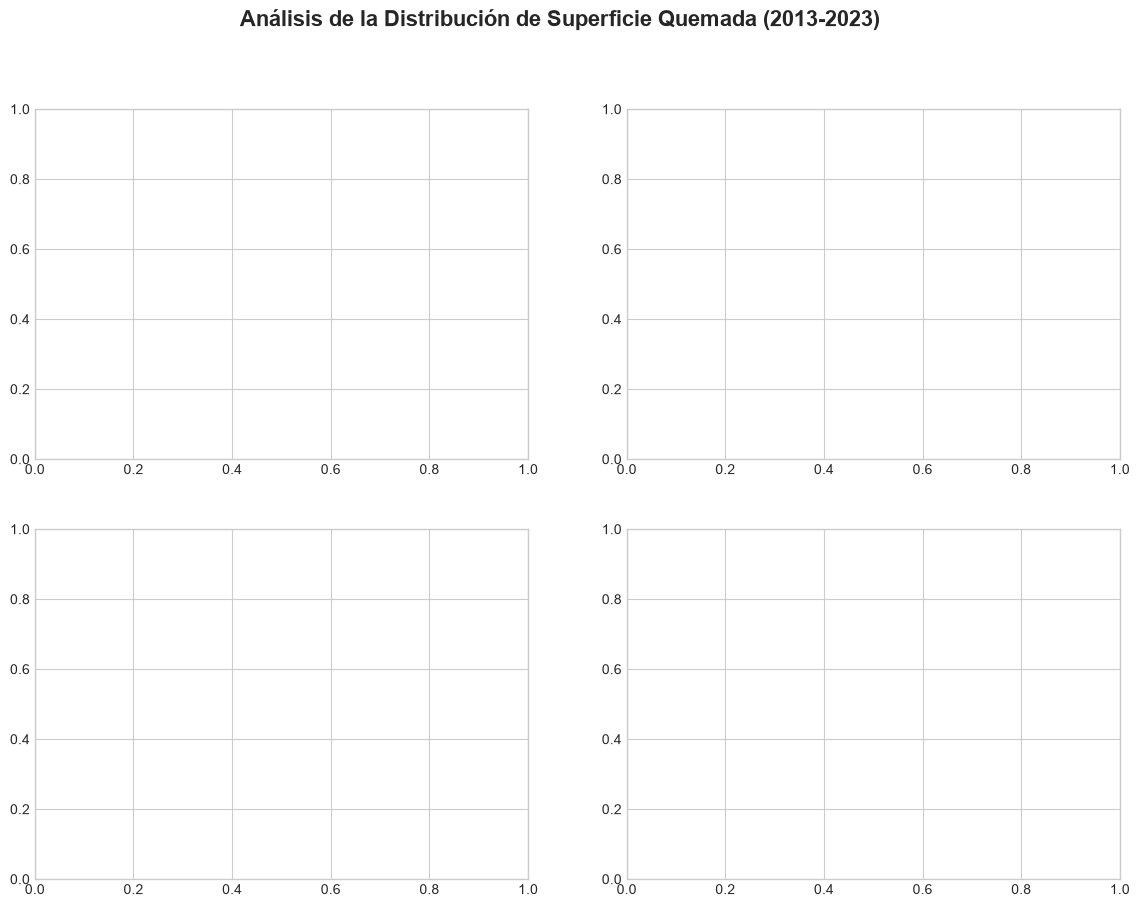

In [23]:
# --- CREAR GRÁFICOS CON MANEJO DE DATOS ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de la Distribución de Superficie Quemada (2013-2023)', 
             fontsize=16, fontweight='bold')

# Convertir a numpy y filtrar valores extremos para mejor visualización
superficie_data = df['superficie_quemada'].to_numpy()

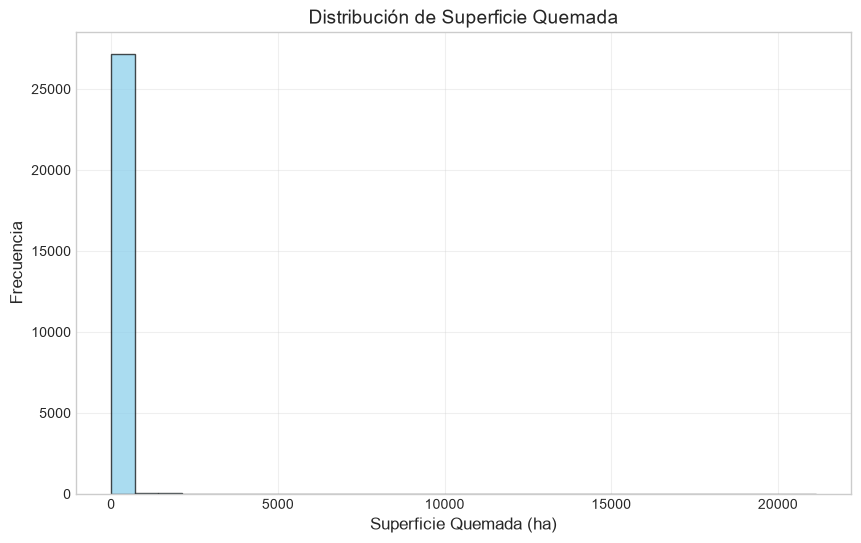

In [24]:
# Crear figura simple
plt.figure(figsize=(10, 6))

# Histograma
plt.hist(superficie_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de Superficie Quemada', fontsize=14)
plt.xlabel('Superficie Quemada (ha)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(True, alpha=0.3)

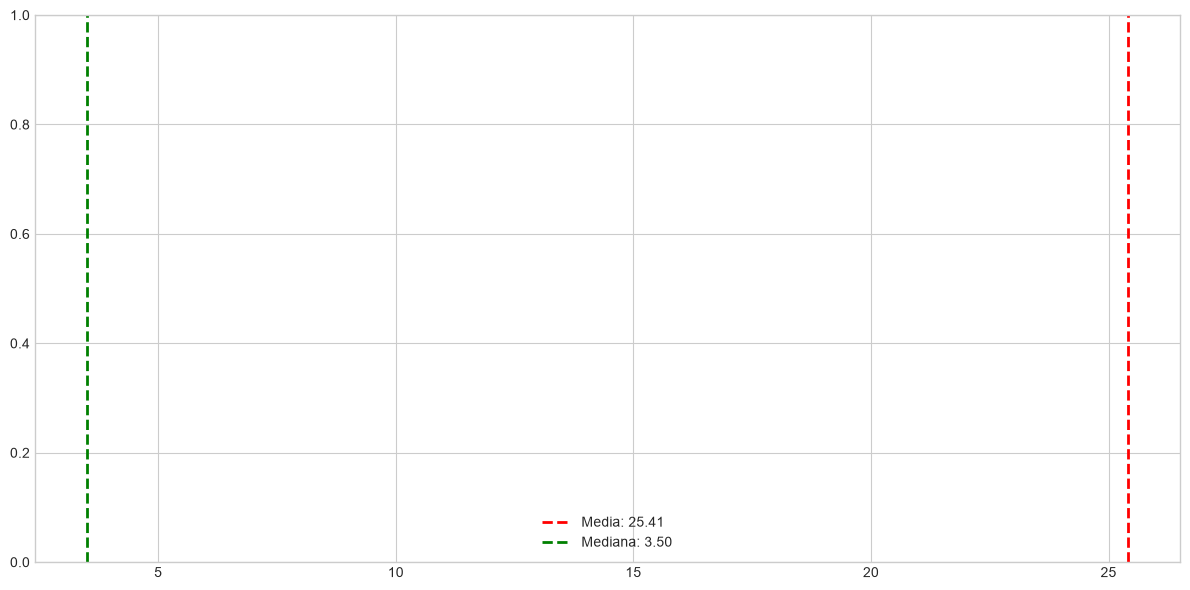

In [25]:
# Mostrar estadísticas en el gráfico
media = np.mean(superficie_data)
mediana = np.median(superficie_data)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\Coder\AppData\Local\Temp\ipykernel_22932\3151117371.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(superficie_data, vert=True, patch_artist=True,


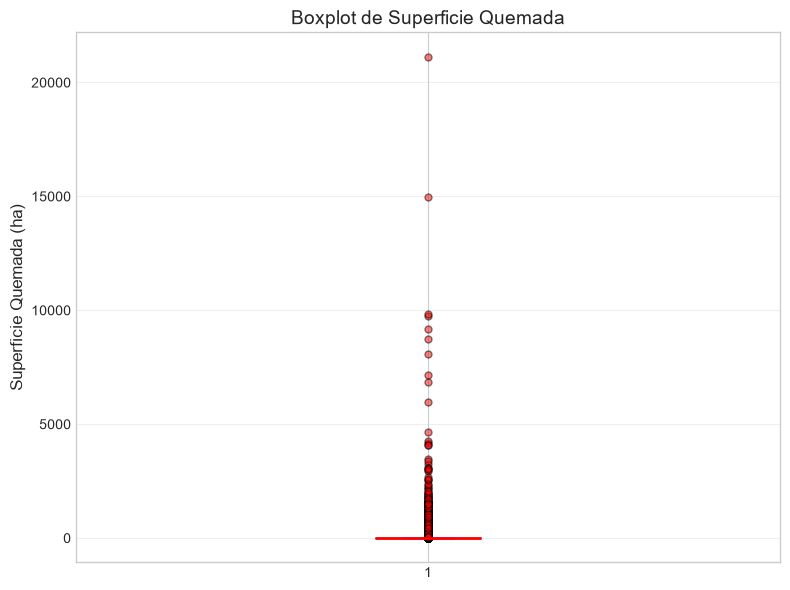

In [26]:
# --- GRÁFICO 2: BOXPLOT ---
plt.figure(figsize=(8, 6))

# Boxplot
plt.boxplot(superficie_data, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))

plt.title('Boxplot de Superficie Quemada', fontsize=14)
plt.ylabel('Superficie Quemada (ha)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

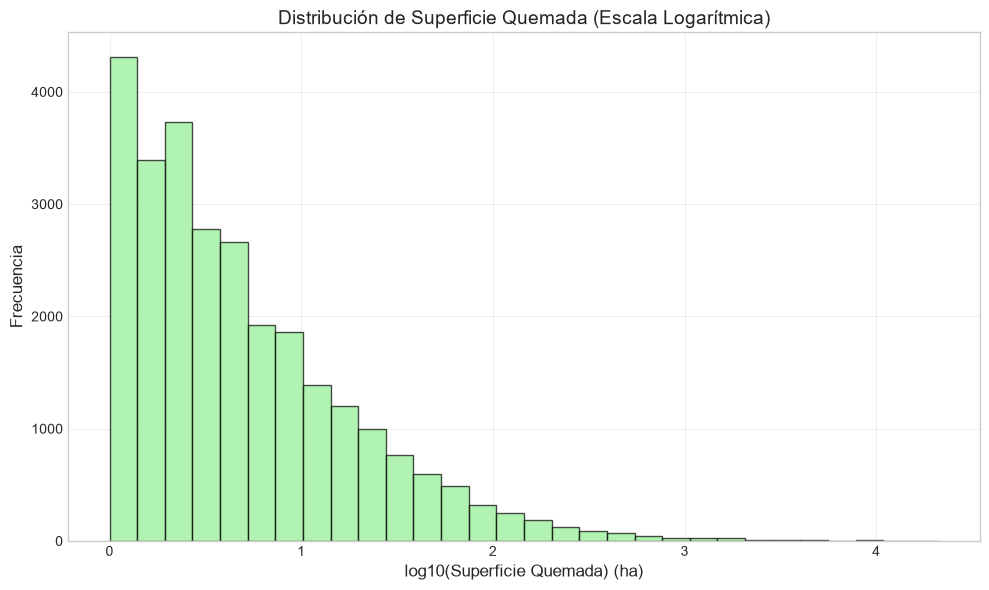

In [27]:
# --- GRÁFICO 3: HISTOGRAMA EN ESCALA LOGARÍTMICA ---
plt.figure(figsize=(10, 6))

# Filtrar valores > 0 para el log
datos_log = superficie_data[superficie_data > 0]

if len(datos_log) > 0:
    plt.hist(np.log10(datos_log), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.title('Distribución de Superficie Quemada (Escala Logarítmica)', fontsize=14)
    plt.xlabel('log10(Superficie Quemada) (ha)', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'No hay datos positivos', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

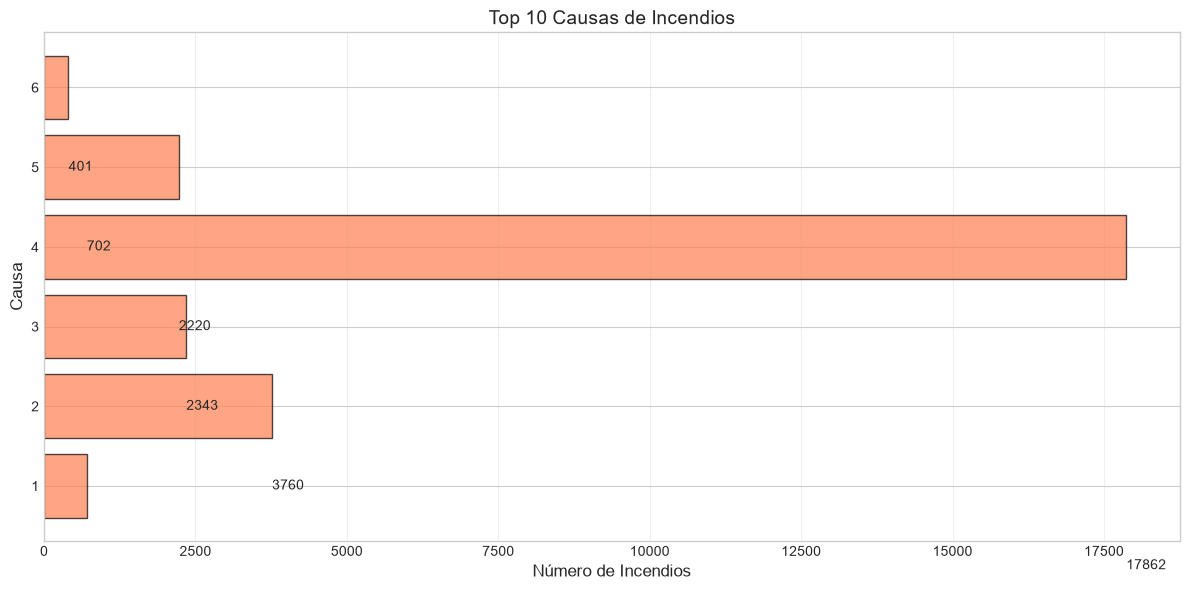

In [28]:
# --- GRÁFICO 4: GRÁFICO DE BARRAS POR CAUSAS ---
# Obtener top 10 causas
causas_count = df.group_by('causa_incendio').agg([
    pl.len().alias('frecuencia')
]).sort('frecuencia', descending=True).head(10)

# Crear gráfico
plt.figure(figsize=(12, 6))

causas = causas_count['causa_incendio'].to_list()
frecuencias = causas_count['frecuencia'].to_numpy()

plt.barh(causas, frecuencias, color='coral', alpha=0.7, edgecolor='black')
plt.title('Top 10 Causas de Incendios', fontsize=14)
plt.xlabel('Número de Incendios', fontsize=12)
plt.ylabel('Causa', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Añadir valores
for i, (causa, freq) in enumerate(zip(causas, frecuencias)):
    plt.text(freq + 5, i, f'{freq}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

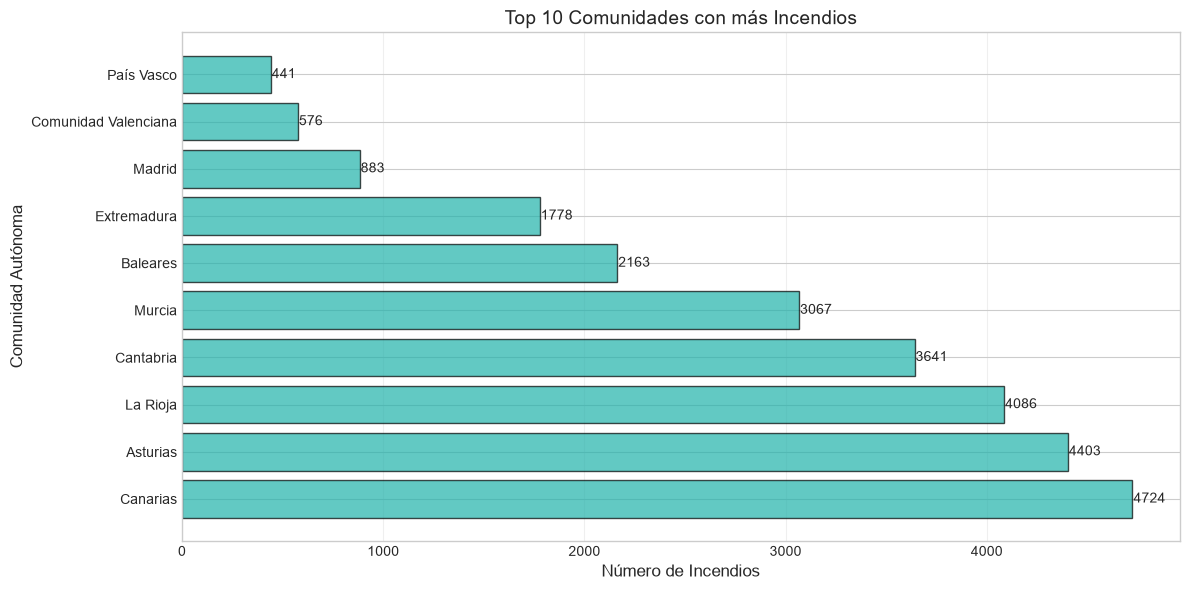

In [29]:
# --- GRÁFICO 5: COMUNIDADES CON MÁS INCENDIOS ---
# Obtener top 10 comunidades
comunidades_count = df.group_by('comunidad_autonoma').agg([
    pl.len().alias('frecuencia')
]).sort('frecuencia', descending=True).head(10)

# Crear gráfico
plt.figure(figsize=(12, 6))

comunidades = comunidades_count['comunidad_autonoma'].to_list()
frecuencias = comunidades_count['frecuencia'].to_numpy()

plt.barh(comunidades, frecuencias, color='lightseagreen', alpha=0.7, edgecolor='black')
plt.title('Top 10 Comunidades con más Incendios', fontsize=14)
plt.xlabel('Número de Incendios', fontsize=12)
plt.ylabel('Comunidad Autónoma', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Añadir valores
for i, (com, freq) in enumerate(zip(comunidades, frecuencias)):
    plt.text(freq + 5, i, f'{freq}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

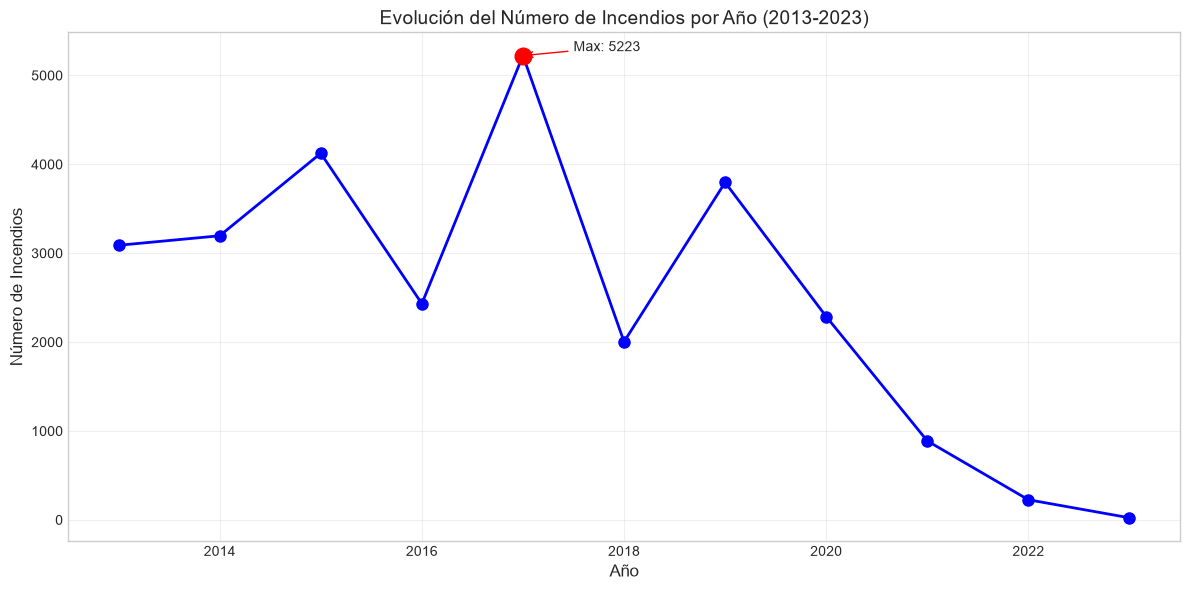

In [30]:
# --- GRÁFICO 6: EVOLUCIÓN TEMPORAL (AÑOS) ---
# Agrupar por año
incendios_por_año = df.group_by('año').agg([
    pl.len().alias('num_incendios')
]).sort('año')

# Crear gráfico
plt.figure(figsize=(12, 6))

años = incendios_por_año['año'].to_numpy()
num_incendios = incendios_por_año['num_incendios'].to_numpy()

plt.plot(años, num_incendios, 'o-', color='blue', linewidth=2, markersize=8)
plt.title('Evolución del Número de Incendios por Año (2013-2023)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Incendios', fontsize=12)
plt.grid(True, alpha=0.3)

# Marcar el año con más incendios
max_idx = np.argmax(num_incendios)
plt.plot(años[max_idx], num_incendios[max_idx], 'ro', markersize=12)
plt.annotate(f'Max: {num_incendios[max_idx]}', 
             xy=(años[max_idx], num_incendios[max_idx]),
             xytext=(años[max_idx]+0.5, num_incendios[max_idx]+50),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10)

plt.tight_layout()
plt.show()

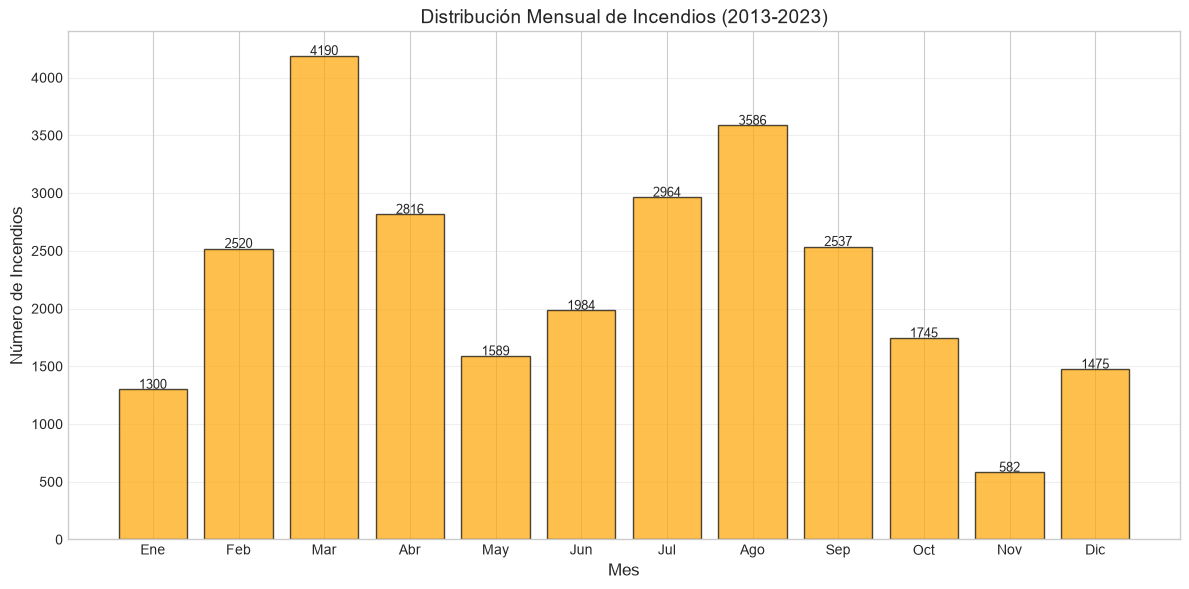

In [31]:
# --- GRÁFICO 7: DISTRIBUCIÓN MENSUAL ---
# Agrupar por mes
incendios_por_mes = df.group_by('mes').agg([
    pl.len().alias('num_incendios')
]).sort('mes')

# Crear gráfico
plt.figure(figsize=(12, 6))

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
num_incendios = incendios_por_mes['num_incendios'].to_numpy()

plt.bar(meses, num_incendios, color='orange', alpha=0.7, edgecolor='black')
plt.title('Distribución Mensual de Incendios (2013-2023)', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de Incendios', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores
for i, (mes, freq) in enumerate(zip(meses, num_incendios)):
    plt.text(i, freq + 5, f'{freq}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()